# Oral Cancer Prediction Project

This notebook walks through a machine learning project to predict oral cancer based on a synthetic dataset. We will perform data cleaning, exploratory data analysis, and train two classification models: Logistic Regression and Random Forest.

## 1. Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

## 2. Loading the Data

In [2]:
try:
    df = pd.read_csv('synthetic_oral_cancer_dataset_noisy.csv')
except FileNotFoundError:
    print("Error: The dataset file 'synthetic_oral_cancer_dataset_noisy.csv' was not found.")

## 3. Data Cleaning and Preprocessing

In [3]:
# Display missing value counts before cleaning
print("--- Missing Values Before Cleaning ---")
print(df.isnull().sum())
print("\n")

--- Missing Values Before Cleaning ---
age                           0
gender                        0
region                        0
education_level           16351
smoking                       0
alcohol_use                   0
betel_nut_use                 0
poor_oral_hygiene             0
diet_quality               4250
oral_lesions                  0
bleeding_gums              4326
persistent_sore_throat     4254
numbness_mouth                0
difficulty_chewing            0
family_history_cancer         0
regular_dental_visits         0
oral_cancer                   0
dtype: int64




In [4]:
# Handle missing values
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object' or pd.api.types.is_categorical_dtype(df[col]):
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].mean(), inplace=True)

# Display missing value counts after cleaning
print("--- Missing Values After Cleaning ---")
print(df.isnull().sum())
print("\n")

--- Missing Values After Cleaning ---
age                       0
gender                    0
region                    0
education_level           0
smoking                   0
alcohol_use               0
betel_nut_use             0
poor_oral_hygiene         0
diet_quality              0
oral_lesions              0
bleeding_gums             0
persistent_sore_throat    0
numbness_mouth            0
difficulty_chewing        0
family_history_cancer     0
regular_dental_visits     0
oral_cancer               0
dtype: int64




C:\Users\nanaa\AppData\Local\Temp\ipykernel_18548\203103019.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\nanaa\AppData\Local\Temp\ipykernel_18548\203103019.py:4: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if df[col].dtype == 'object' or pd.api.types.is_categorical_dtype(df[col]):
C:\Users\nanaa\AppData\Local\Temp\ipykernel_18548\203103019.py:7: FutureWarning: 

In [5]:
# One-hot encode categorical features
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows of the cleaned data
print("--- Cleaned and Preprocessed Data (First 5 Rows) ---")
df.head()

--- Cleaned and Preprocessed Data (First 5 Rows) ---


,age,smoking,alcohol_use,betel_nut_use,poor_oral_hygiene,oral_lesions,bleeding_gums,persistent_sore_throat,numbness_mouth,difficulty_chewing,family_history_cancer,regular_dental_visits,oral_cancer,gender_Male,region_Semi-Urban,region_Urban,education_level_Secondary,education_level_Tertiary,diet_quality_Good,diet_quality_Poor
0,53,1,0,0,1,0,1.0,0.0,0,0,0,0,0,True,False,True,False,False,False,True
1,43,0,0,0,0,0,1.0,1.0,0,0,0,1,0,False,True,False,False,False,True,False
2,55,0,0,0,1,1,1.0,0.0,0,0,0,0,1,True,False,False,True,False,True,False
3,68,0,0,0,1,0,1.0,1.0,0,0,0,0,1,True,False,True,False,False,False,False
4,42,0,0,1,0,0,0.0,1.0,1,1,0,0,1,False,False,False,False,False,False,False


## 4. Exploratory Data Analysis (EDA)

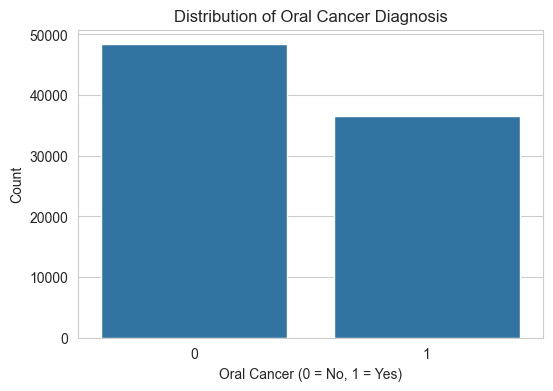

In [6]:
# Set the style for the plots
sns.set_style("whitegrid")

# 1. Distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='oral_cancer', data=df)
plt.title('Distribution of Oral Cancer Diagnosis')
plt.xlabel('Oral Cancer (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.savefig('oral_cancer_distribution.png') # Save the plot
plt.show()

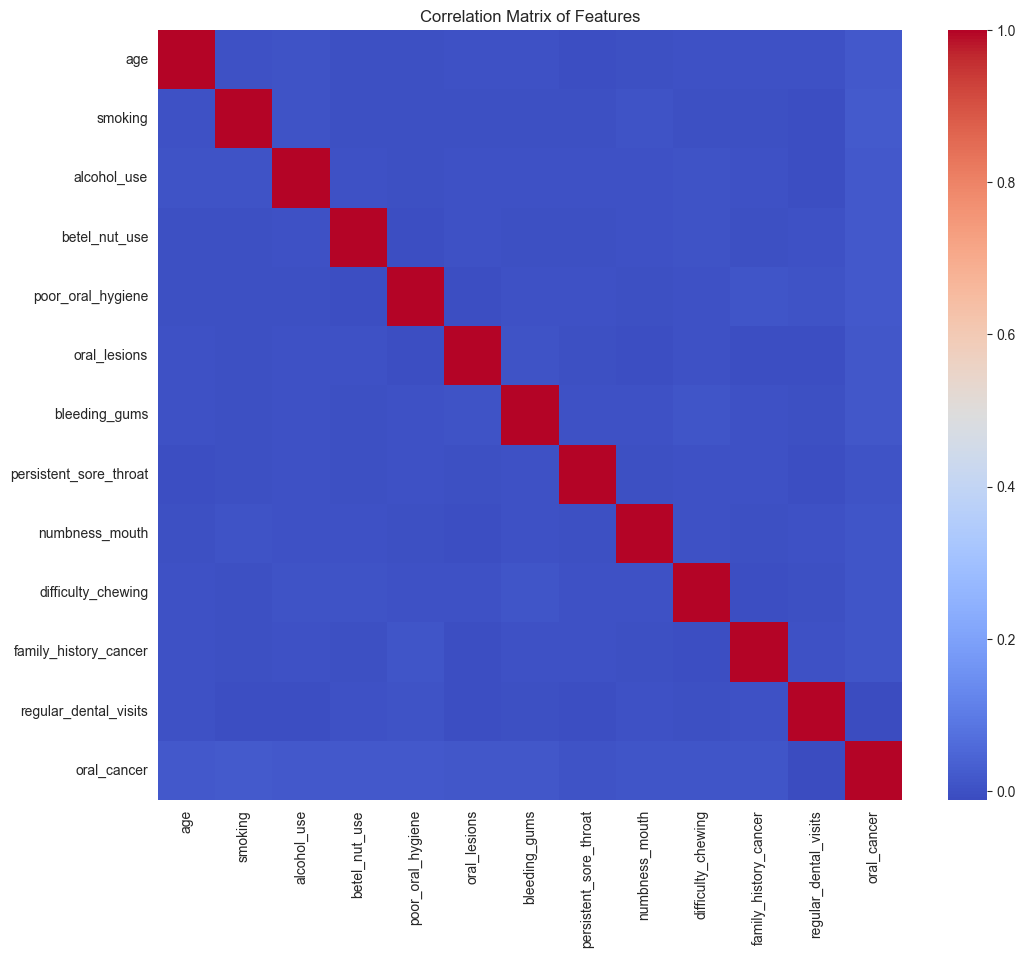

In [7]:
# 2. Correlation matrix of numerical features
plt.figure(figsize=(12, 10))
recal_numerical_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[recal_numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Features')
plt.savefig('correlation_matrix.png') # Save the plot
plt.show()

## 5. Model Training and Evaluation

In [8]:
# Define features (X) and target (y)
X = df.drop('oral_cancer', axis=1)
y = df['oral_cancer']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Logistic Regression

In [9]:
print("--- Training Logistic Regression Model ---")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
print("--- Logistic Regression - Classification Report ---")
print(classification_report(y_test, y_pred_log_reg))

--- Training Logistic Regression Model ---
--- Logistic Regression - Classification Report ---
              precision    recall  f1-score   support

           0       0.57      0.99      0.72      9670
           1       0.51      0.01      0.02      7315

    accuracy                           0.57     16985
   macro avg       0.54      0.50      0.37     16985
weighted avg       0.54      0.57      0.42     16985



### Random Forest

In [10]:
print("--- Training Random Forest Model ---")
rand_forest = RandomForestClassifier(random_state=42)
rand_forest.fit(X_train, y_train)
y_pred_rand_forest = rand_forest.predict(X_test)
print("--- Random Forest - Classification Report ---")
print(classification_report(y_test, y_pred_rand_forest))

--- Training Random Forest Model ---
--- Random Forest - Classification Report ---
              precision    recall  f1-score   support

           0       0.58      0.67      0.62      9670
           1       0.45      0.35      0.39      7315

    accuracy                           0.53     16985
   macro avg       0.51      0.51      0.51     16985
weighted avg       0.52      0.53      0.52     16985



## 6. Conclusion and Next Steps

Neither model is performing well, especially the Logistic Regression model, which has an extremely low recall for the positive class. The Random Forest model is better, but still not great.

Here are some potential reasons for the poor performance and what we can do to improve the models:

1.  **Data Quality:** The dataset is "noisy," as the filename suggests. This could mean there are errors or inconsistencies in the data that are making it difficult for the models to learn.
2.  **Feature Engineering:** We could try to create new features from the existing ones that might have a stronger relationship with the target variable.
3.  **Model Tuning:** We can probably get better performance by tuning the hyperparameters of the models (e.g., using `GridSearchCV` or `RandomizedSearchCV`).
4.  **Class Imbalance:** If there's a significant class imbalance we can try techniques like over-sampling the minority class (e.g., using SMOTE) or under-sampling the majority class.
5.  **Try other models:** We could try other, more powerful models like Gradient Boosting (e.g., XGBoost, LightGBM) to see if they perform better.